# Single Layer Perceptron

## Time Complexity

For each training example $x = (x_1, x_2, ..., x_n)$, the perceptron computes the weighted sum:

$$
s = \sum_{i=0}^{n} w_i x_i
$$

This corresponds to a **dot product** between the weight vector and the input vector.

Computing this operation requires approximately **n multiplications and n additions**, which leads to a complexity of:

$$
O(n)
$$

Let:

- $m$  be the number of training samples
- $n$  be the number of features
- $T$  be the number of training iterations (epochs)

For each sample, the algorithm:

1. Computes the perceptron output $O(n)$
2. Updates the weights if the prediction is incorrect $O(n)$

Therefore, for one pass over the dataset:

$$
O(mn)
$$

For $T$ iterations:

$$
O(Tmn)
$$

### Final Time Complexity

$$
O(Tmn)
$$


## Space Complexity

The perceptron stores:

- The **weight vector** $w$ of size $n$
- The **bias term** $w_0$

Thus, the memory required for the model is:

$$
O(n)
$$

If we also include the dataset containing $m$ samples with $n$ features:

$$
O(mn)
$$

### Final Space Complexity

- Model only: $O(n)$
- Including dataset: $O(mn)$

### Dataset Generation
 Generating and visualizing a synthetic two-class dataset using `make_blobs` to serve as the foundation for training the perceptron.

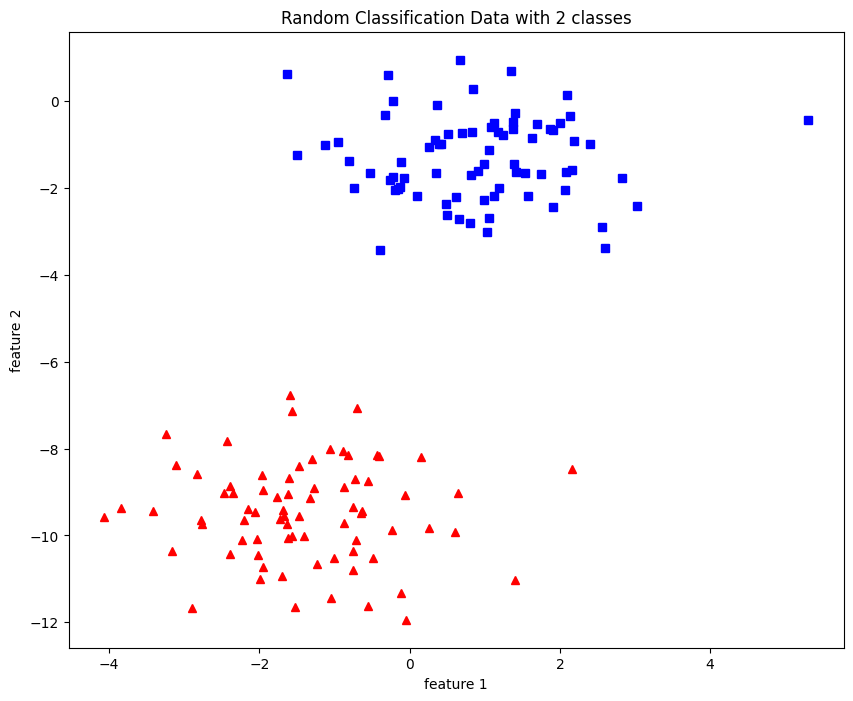

In [114]:
from sklearn import datasets
import matplotlib.pyplot as plt
X, y = datasets.make_blobs (n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2)
#Plotting 
fig = plt.figure(figsize=(10,8))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')
plt.show()

### Activation Function
This function implements the **Heaviside step activation function**, which returns 1 if the input is positive and 0 otherwise, allowing the perceptron to perform binary classification.

In [115]:
def acti_func(x):
    if x > 0:
        return 1
    else:
        return 0


This function implements the **Perceptron training algorithm**, which iteratively updates the weights using the learning rate whenever a sample is misclassified, and records the number of classification errors at each epoch.

When the perceptron misclassifies a sample, the weights are updated using the following rule:

$$
w = w + \eta (y - \hat{y}) x
$$

where:

- $w$ : weight vector  
- $\eta$ : learning rate  
- $y$ : true label  
- $\hat{y}$ : predicted label  
- $x$ : input vector (including the bias term)

This rule adjusts the weights in the direction that reduces the classification error.

In [116]:
import numpy as np

def perceptron(X, y, lr, epochs):

    # m-> number of training examples
    # n-> number of features
    m, n = X.shape

    # Weights initialization
    w = np.zeros((n+1, 1))

    # List of errors
    n_miss_list = []

    # Training
    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            # Add bias
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)
            # Prediction
            y_hat = acti_func(np.dot(x_i.T, w))
            # If error
            if ( np.squeeze(y_hat) - y[idx] ) != 0:
                # Update weights
                w = w + lr * (y[idx] - np.squeeze(y_hat)) * x_i
                # Increment miss
                n_miss += 1
        n_miss_list.append(n_miss)

    return w, n_miss_list


In [117]:
w, errors = perceptron(X, y, lr=0.01, epochs=5)

print("weights:")
print(w)

print("errors:")
print(errors)

weights:
[[0.1       ]
 [0.01488595]
 [0.01693843]]
errors:
[14, 0, 0, 0, 0]


This function plots the dataset and visualizes the perceptron's **decision boundary**, which represents the line that separates the two classes based on the learned weights.

In [118]:
def plot_decision_boundary(X, y, w):

    # Plot points
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', marker='^')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', marker='s')

    # Separation line
    x1 = np.array([min(X[:,0]), max(X[:,0])])

    m = -w[1][0] / w[2][0]
    c = -w[0][0] / w[2][0]

    x2 = m * x1 + c

    plt.plot(x1, x2, 'k-', label="Decision Boundary")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.show()

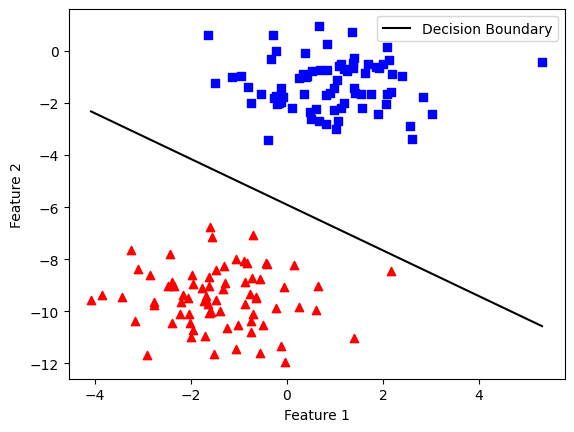

In [119]:
plot_decision_boundary(X,y,w)

<hr>

# Part 2


## Dataset Generation with $\sigma_1^2 = \sigma_2^2 = 0.25$

We generate a dataset of 250 points split into two classes:

- **Class $y = 1$**: 125 points drawn from $\mathcal{N}(\mu_1, \sigma^2 I)$ with $\mu_1 = [-1, 0]^T$
- **Class $y = 0$**: 125 points drawn from $\mathcal{N}(\mu_2, \sigma^2 I)$ with $\mu_2 = [1, 0]^T$

with $\sigma^2 = 0.25$ .

The dataset is then passed directly to the perceptron (no train/test split here), trained with:
- **Learning rate** $\eta = 0.01$
- **Epochs** $T = 100$

We then print the final weights and error curve, and plot the decision boundary.

In [120]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.utils import shuffle

def generate_dataset(n_samples=1000, cluster_std1=0.25, center_box1=(1, 0),
                     cluster_std2=0.25, center_box2=(-1, 0), random=False):

    # Generate the first cluster (class 0)
    if random:
        X1, y1 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1,cluster_std=cluster_std1, random_state=2, center_box=center_box1)
        X2, y2 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1,cluster_std=cluster_std2, random_state=2, center_box=center_box2)
    else:
        X1, y1 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1,cluster_std=cluster_std1, center_box=center_box1)
        X2, y2 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1, cluster_std=cluster_std2, center_box=center_box2)

    # Assign class 1 to the second cluster
    y2 = np.full((n_samples,), 1)

    # Combine the two clusters into a single dataset
    X = np.concatenate((X1, X2), axis=0)  # Combine features
    y = np.concatenate((y1, y2), axis=0)  # Combine labels

    # Shuffle the dataset to mix the two classes
    X, y = shuffle(X, y, random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    return X_train, X_test, y_train, y_test

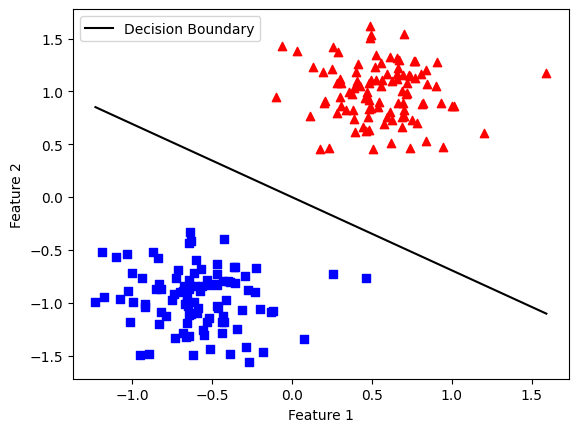

In [121]:
X_train, X_test, y_train, y_test = generate_dataset(n_samples=125,random=True)
w2, errors2 = perceptron(X_train, y_train, lr=0.01, epochs=1000)
plot_decision_boundary(X_train, y_train, w2)

## Dataset Generation with $\sigma_1^2 = \sigma_2^2 = 0.75$

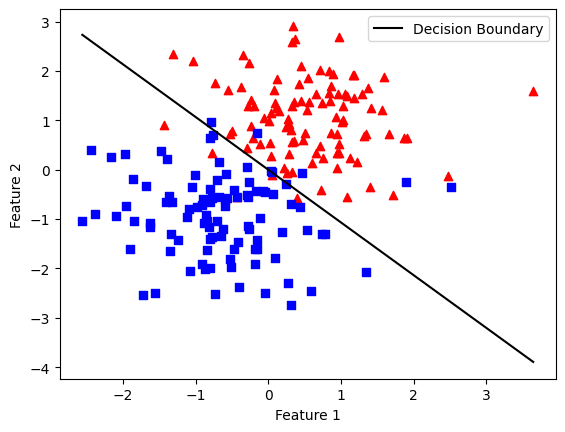

In [122]:
X_train2, X_test2, y_train2, y_test2=generate_dataset(n_samples=125,cluster_std1=0.75,cluster_std2=0.75,random=True)
w3, errors3 = perceptron(X_train2, y_train2, lr=0.01, epochs=1000)
plot_decision_boundary(X_train2, y_train2, w3)